### Libraries

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    # Figure
    "figure.figsize": (15, 12),
    "figure.dpi": 120,

    # Fonts
    "font.size": 30,          # base font size
    "axes.titlesize": 30,     # title
    "axes.labelsize": 30,     # x,y labels

    # Tick labels
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,

    # Tick direction (correct way)
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Legend
    "legend.fontsize": 30,
    "legend.frameon": False,

    # Lines
    "lines.linewidth": 2,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.3,

    # Better layout
    "figure.autolayout": True,

    "text.usetex": False,   # set True if LaTeX installed
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

### Bus and EV Dataset

In [2]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]

# Aggregating
df = (
    df.groupby("timestamp")["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [3]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_26792\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


### Plotting Dataset

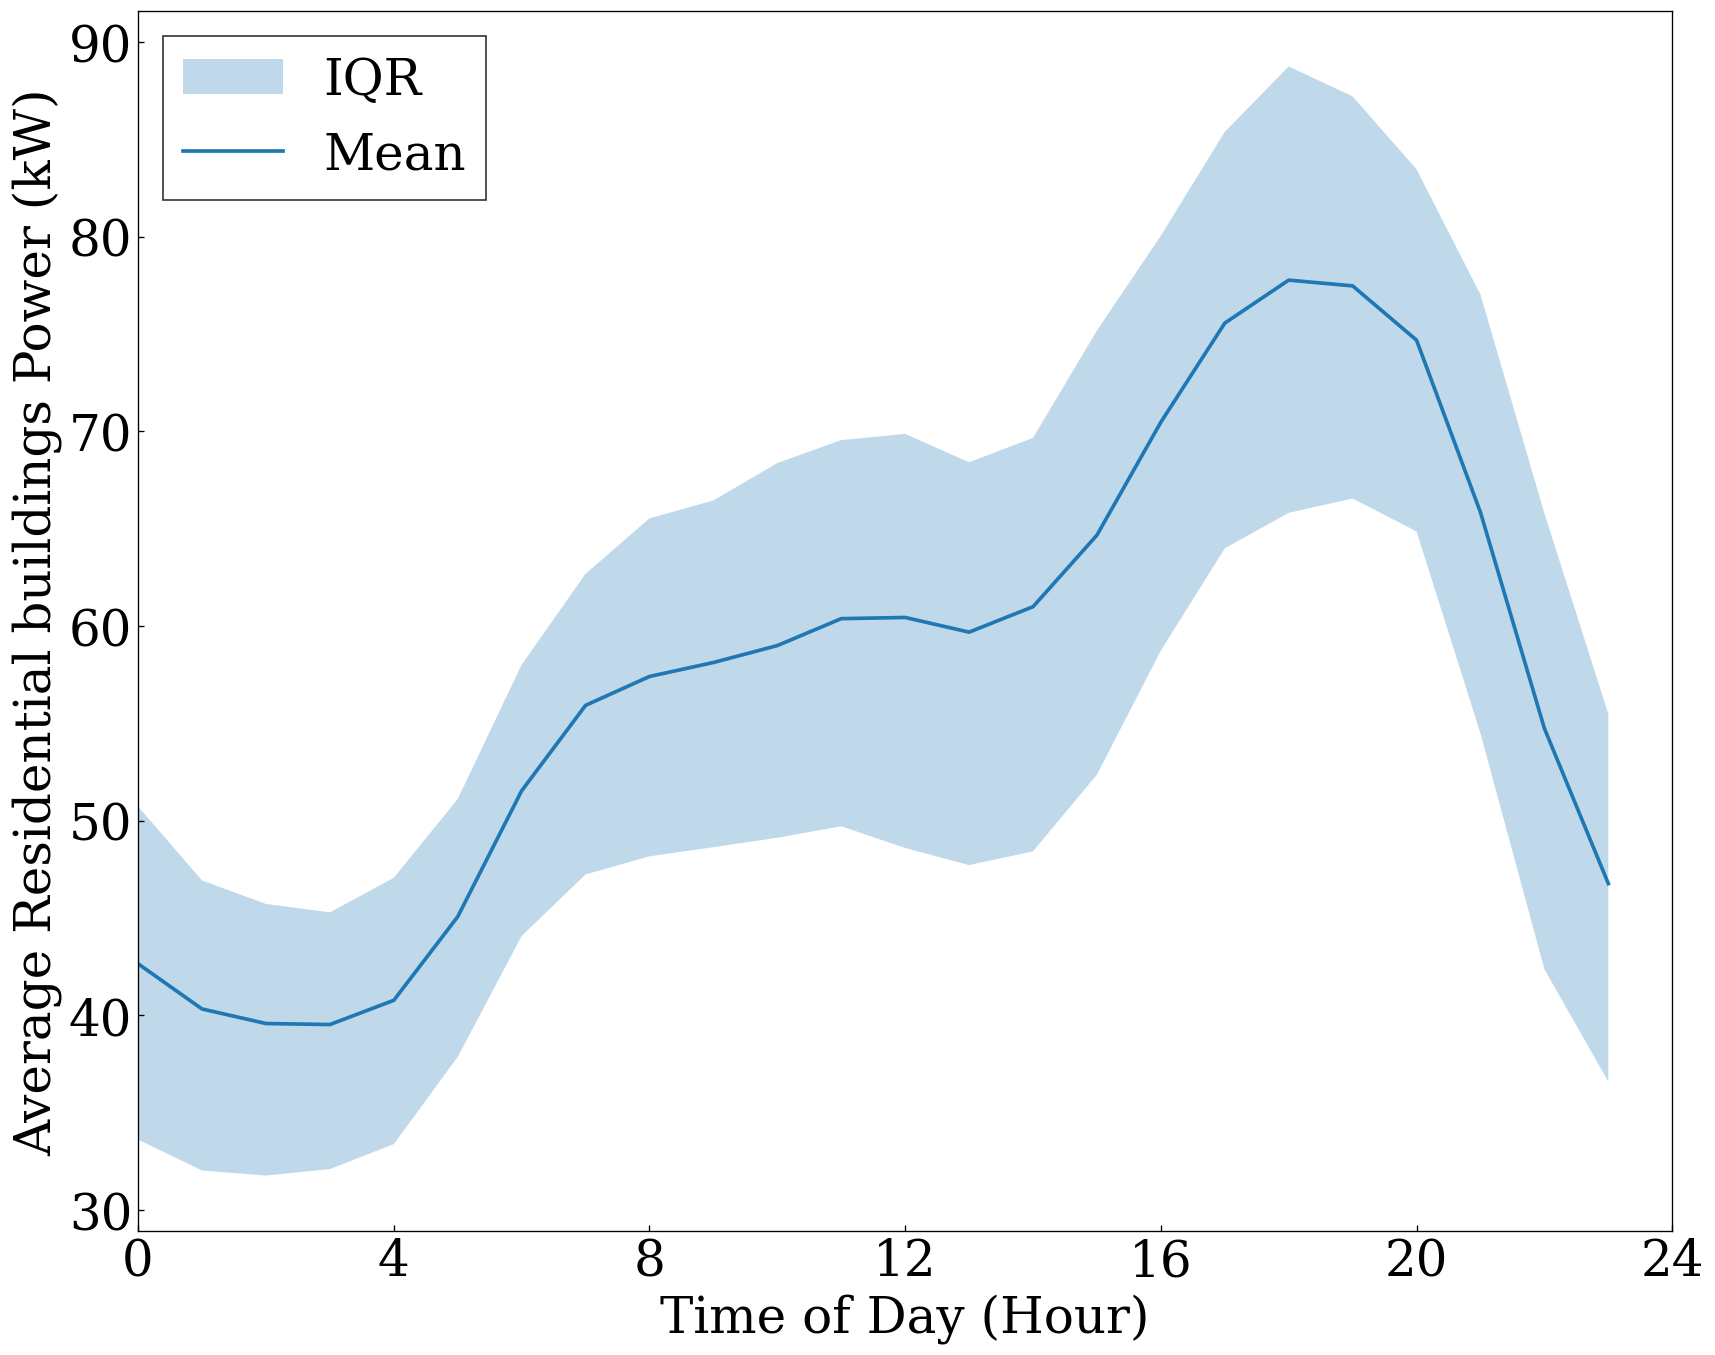

In [4]:
# base_load = bus_load_kw_final.mean(axis=1)
base_load = df.copy()
base_load.set_index('timestamp', drop = True, inplace = True)


def hourly_mean_iqr(series):
    df = pd.DataFrame({"value": series})
    df["hour"] = df.index.hour

    stats = df.groupby("hour")["value"].agg([
        ("q25", lambda x: np.percentile(x, 25)),
        ("mean", "mean"),
        ("q75", lambda x: np.percentile(x, 75)),
    ])
    return stats

res_stats = hourly_mean_iqr(base_load['out.electricity.net.energy_consumption'])

# Residential power plot
plt.figure(figsize=(15, 12))
h = res_stats.index.to_numpy()
m = res_stats["mean"].to_numpy()
q25 = res_stats["q25"].to_numpy()
q75 = res_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Average Residential buildings Power (kW)")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


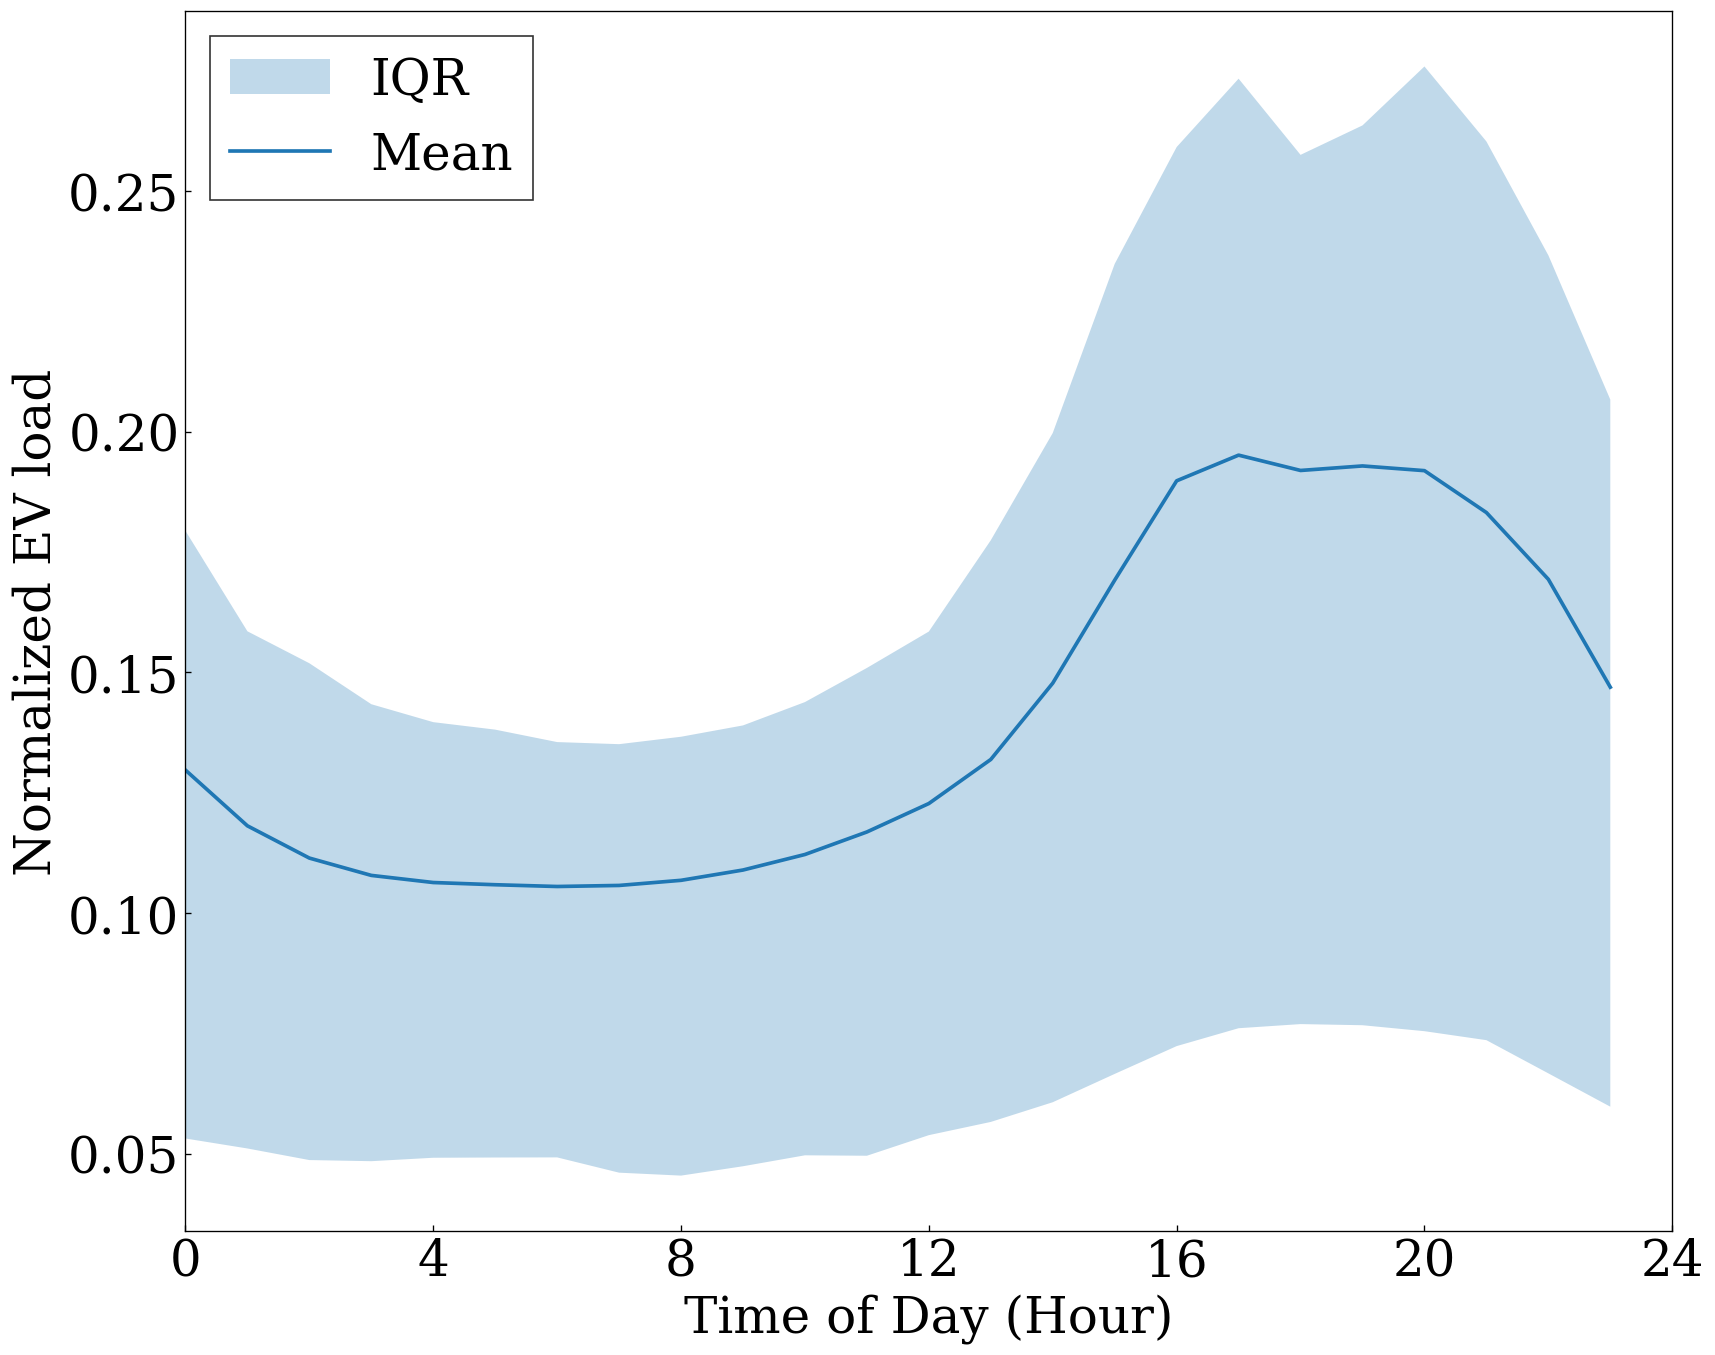

In [5]:
ev_df_plot = ev_df.copy()
ev_df_plot['Synthetic_7_2kW'] = ev_df_plot['Synthetic_7_2kW']/ev_df_plot['Synthetic_7_2kW'].max()

ev_stats = hourly_mean_iqr(ev_df_plot['Synthetic_7_2kW']) 

# Residential power plot
plt.figure(figsize=(15, 12))
h = ev_stats.index.to_numpy()
m = ev_stats["mean"].to_numpy()
q25 = ev_stats["q25"].to_numpy()
q75 = ev_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Normalized EV load")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


### Gurobi Formulation (CVXPY Library)

In [6]:
# test
# p0 = 14
# L = np.array([13, 11, 10], dtype=float)
# lhat = np.array([0.5, 2, 0.9], dtype=float)
# lhat = lhat / np.max(lhat)

L = df['out.electricity.net.energy_consumption'].values
lhat = ev_df['Synthetic_7_2kW']/ev_df['Synthetic_7_2kW'].max()
lhat = lhat.values
p0 = 1.1 * np.max(L) # 10% headroom


T = len(L)
# alpha = 1/3 - 0.001
alpha = 0.99

# Dynamic capacity
P_dyn = (p0 - L) / lhat

beta = (1 - alpha) * T

P = cp.Variable(name="P")
eta = cp.Variable(nonneg=True, name="eta")
v = cp.Variable(T, nonneg=True, name="v")   # capacity-dimensional intervention

constraints = [
    P <= P_dyn + v - eta,
    cp.sum(v) <= beta * eta
    # p_curt <= rho * P * lhat
]

problem = cp.Problem(cp.Maximize(P), constraints)
problem.solve(solver=cp.CLARABEL, verbose = False)


u = np.maximum(0, P.value * lhat + L - p0)
active_slots = np.where(u > 1e-6)[0]

theoretical_u = lhat * (v.value - eta.value)

print("lhat =", lhat)
print("P_dyn =", P_dyn)
print("optimal P =", P.value)
print("eta =", eta.value)
print("v =", v.value)
print("sum(v) =", np.sum(v.value))
print("budget RHS =", beta * eta.value)

print("u =", u)
print("Ttheoretical u", theoretical_u)

print("theoretical max number of interventions =", int(np.floor((1-alpha)*T)))
print("actual intervention slots =", active_slots)
print("actual number of interventions =", len(active_slots))

lhat = [0.03363111 0.03362708 0.03362304 ... 0.24949778 0.24777363 0.24604948]
P_dyn = [2331.40083427 2300.1881005  2295.91368314 ...  252.29723973  250.49316541
  258.0602917 ]
optimal P = 77.59063903612214
eta = 16.86718894826234
v = [3.46169951e-11 3.46157304e-11 3.46155572e-11 ... 3.46308781e-11
 3.46307543e-11 3.46312952e-11]
sum(v) = 5910.263007472575
budget RHS = 5910.263007471129
u = [0. 0. 0. ... 0. 0. 0.]
Ttheoretical u [-0.5672623  -0.56719424 -0.56712619 ... -4.20832612 -4.17924457
 -4.15016303]
theoretical max number of interventions = 350
actual intervention slots = [19365 19648 20710 20711 30119 30120 30598 30599 30600 31179 31464 31465
 31466 31467 31468 31469 31470 31857 31858 31859 31860 31861 31862 32235
 32341 32342 32343 32516 32517 32518 32519 32520 32521 32522 32523 32524
 32525 32526 32527 32528 32529 32530 32531 32532 32533 32535 32802 32803
 32804 32805 32808 32809 32810 32811 32812 32813 32814 32815 32905 32906
 32907 32908 32909 32996 32997 32998 32999 33000

### Projected Gradient Descent

In [7]:
def project(x, P_dyn, beta, n_proj_iter=200):
    """
    Approximating projection onto:

        P <= P_dyn[t] + v[t] - eta
        sum(v) <= beta * eta
        eta >= 0
        v[t] >= 0

    x = [P, eta, v_1, ..., v_T]
    """

    x = np.array(x, dtype=float).copy()
    P_dyn = np.array(P_dyn, dtype=float)

    T = len(P_dyn)

    for _ in range(n_proj_iter):

        # eta >= 0, v >= 0
        x[1] = max(x[1], 0.0)
        x[2:] = np.maximum(x[2:], 0.0)

        # sum(v) <= beta * eta
        eta = x[1]
        v = x[2:]

        violation = np.sum(v) - beta * eta

        if violation > 0:
            denom = beta**2 + T

            x[1] += violation * beta / denom
            x[2:] -= violation / denom

            x[1] = max(x[1], 0.0)
            x[2:] = np.maximum(x[2:], 0.0)

        # P <= P_dyn[t] + v[t] - eta
        # equivalent: P + eta - v[t] <= P_dyn[t]
        P = x[0]
        eta = x[1]
        v = x[2:]

        violations = P + eta - v - P_dyn
        active_idx = np.where(violations > 0)[0]

        if len(active_idx) > 0:
            corr = violations[active_idx] / 3.0

            x[0] -= np.sum(corr)
            x[1] -= np.sum(corr)
            x[2 + active_idx] += corr

            x[1] = max(x[1], 0.0)
            x[2:] = np.maximum(x[2:], 0.0)

    return x

In [8]:
def projected_gradient_descent(
    f,
    grad_f,
    x0,
    P_dyn,
    beta,
    t=0.1,
    decay=0.001,
    max_iter=1000,
    tol=1e-6,
    verbose=False
):
    x = project(np.array(x0, dtype=float), P_dyn, beta)
    history = [f(x)]

    for k in range(max_iter):

        # decreasing step size
        t_k = t / (1 + decay * k)

        grad = grad_f(x)

        # gradient step
        y = x - t_k * grad

        # projection step
        x_new = project(y, P_dyn, beta)

        history.append(f(x_new))

        # stopping criterion
        if np.linalg.norm(x_new - x) < tol:
            x = x_new
            break

        x = x_new

        if verbose and k % 100 == 0:
            print(
                f"iter {k+1}: step size = {t_k:.6e}, "
                f"f(x) = {f(x):.6f}, P = {x[0]:.6f}"
            )

    return x, history

### PGD Run

In [9]:
L = df['out.electricity.net.energy_consumption'].values
lhat = ev_df['Synthetic_7_2kW']/ev_df['Synthetic_7_2kW'].max()
lhat = lhat.values
p0 = 1.1 * np.max(L) # 10% headroom


T = len(L)
# alpha = 1/3 - 0.001
alpha = 0.99

# Dynamic capacity
P_dyn = (p0 - L) / lhat

beta = (1 - alpha) * T

# Objective
def f(x):
    P = x[0]
    return -P

# Gradient of the objective
def grad_f(x):
    g = np.zeros_like(x)
    g[0] = -1.0
    return g

In [10]:
# Initial conditions
P_init = np.min(P_dyn)
eta_init = 1.0
v_init = np.maximum(P_init - P_dyn + eta_init, 0)

x0 = np.concatenate([[P_init], [eta_init], v_init])
x0 = project(x0, P_dyn, beta)

x_star, history = projected_gradient_descent(
    f=f,
    grad_f=grad_f,
    # project=project,
    x0=x0,
    P_dyn = P_dyn,
    beta = beta,
    t=0.5,
    decay=0.0001,
    max_iter=20000,
    tol=1e-10,
    verbose=True
)

P_star = x_star[0]
eta_star = x_star[1]
v_star = x_star[2:]
u = np.maximum(0, P_star * lhat + L - p0)

print("Optimal P from PGD:", P_star)
print("eta:", eta_star)
print("sum(v):", np.sum(v_star))
print("beta * eta:", beta * eta_star)

iter 1: step size = 5.000000e-01, f(x) = -46.506165, P = 46.506165
iter 101: step size = 4.950495e-01, f(x) = -53.052387, P = 53.052387
iter 201: step size = 4.901961e-01, f(x) = -54.140236, P = 54.140236
iter 301: step size = 4.854369e-01, f(x) = -56.719667, P = 56.719667
iter 401: step size = 4.807692e-01, f(x) = -58.656038, P = 58.656038
iter 501: step size = 4.761905e-01, f(x) = -56.036481, P = 56.036481
iter 601: step size = 4.716981e-01, f(x) = -55.993456, P = 55.993456
iter 701: step size = 4.672897e-01, f(x) = -61.283963, P = 61.283963
iter 801: step size = 4.629630e-01, f(x) = -59.405967, P = 59.405967
iter 901: step size = 4.587156e-01, f(x) = -59.408479, P = 59.408479
iter 1001: step size = 4.545455e-01, f(x) = -62.473290, P = 62.473290
iter 1101: step size = 4.504505e-01, f(x) = -61.063919, P = 61.063919
iter 1201: step size = 4.464286e-01, f(x) = -62.565116, P = 62.565116
iter 1301: step size = 4.424779e-01, f(x) = -57.915355, P = 57.915355
iter 1401: step size = 4.385965e

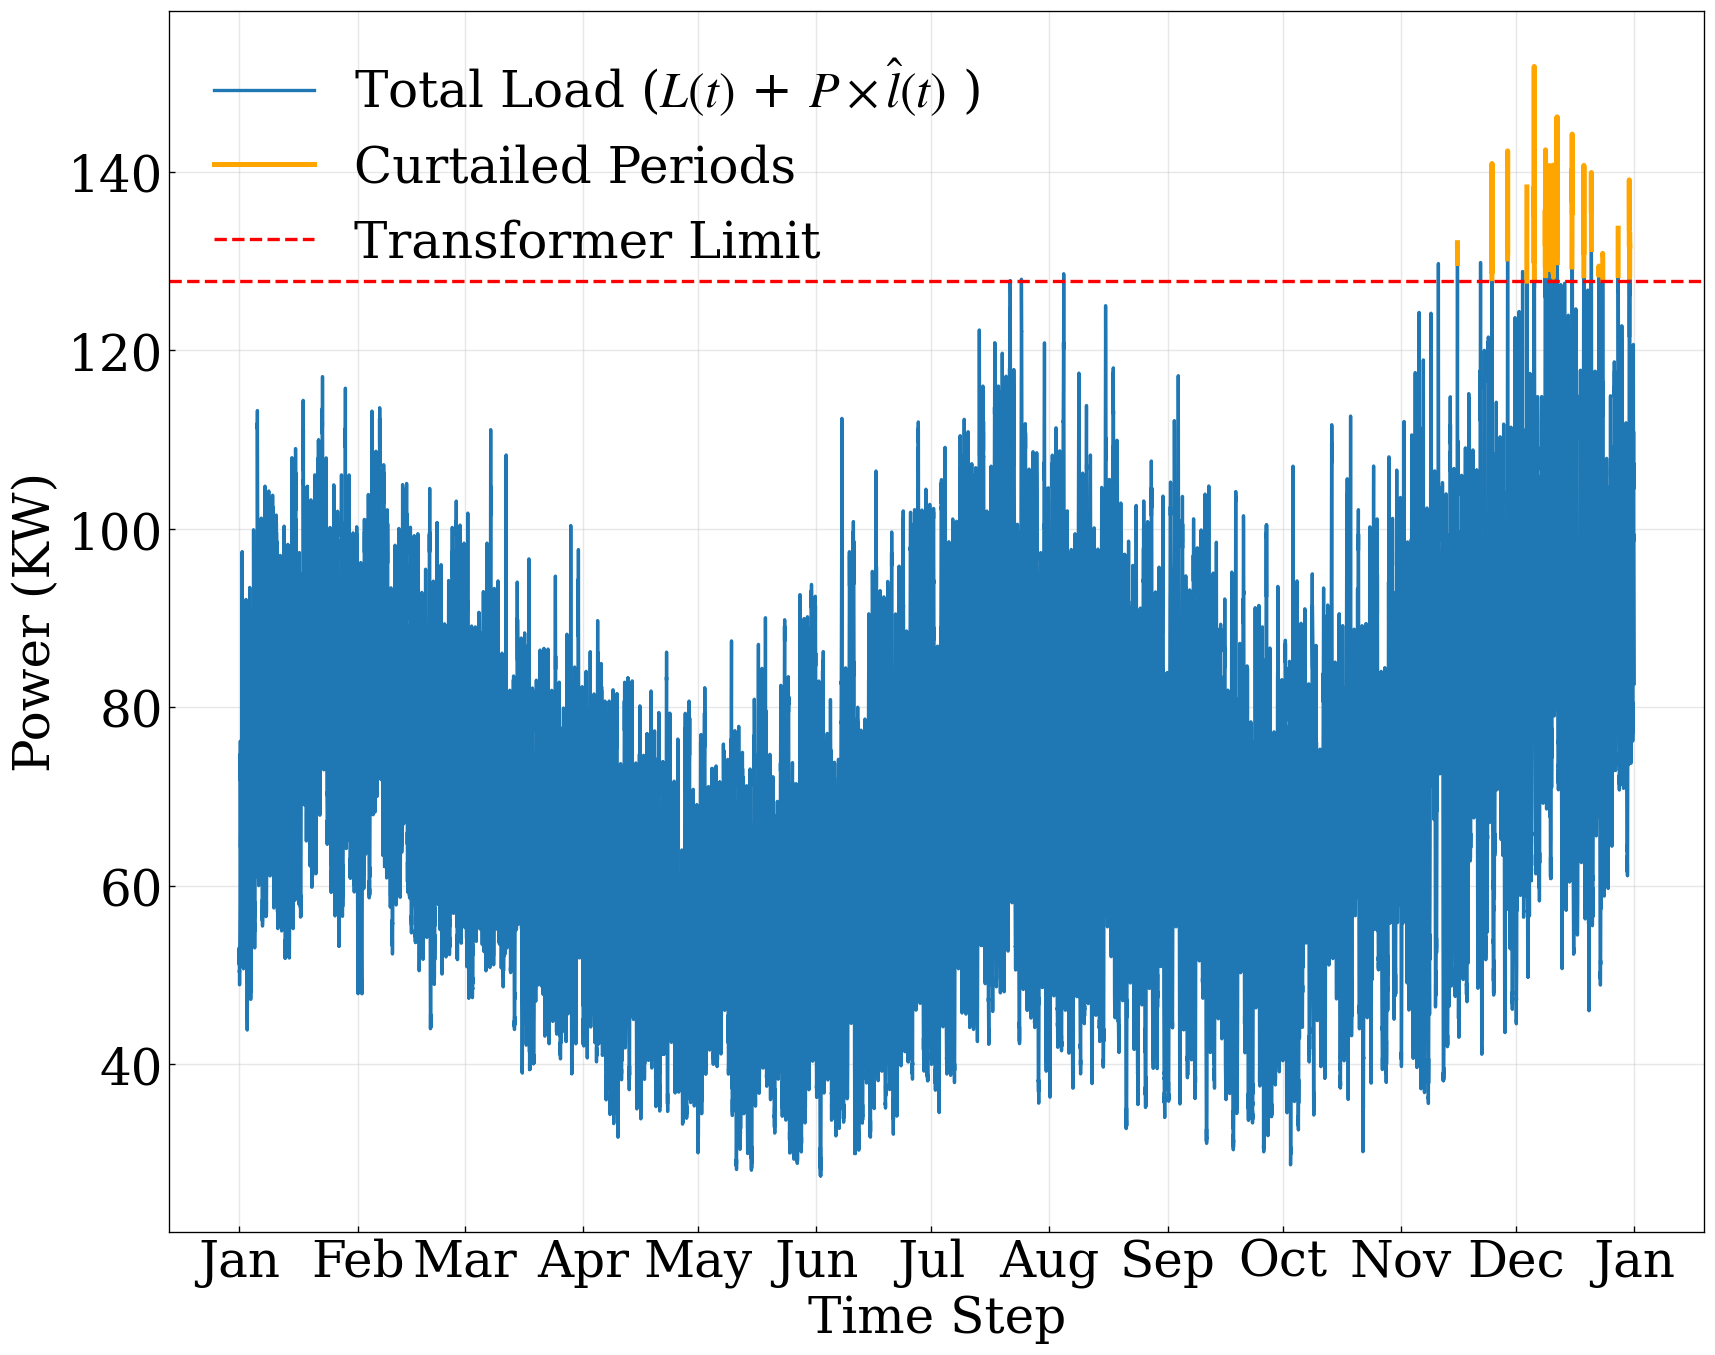

In [11]:
### Output plots


u = np.maximum(0, P_star * lhat + L - p0)
curt_idx = u > 0.000001
total_load = np.asarray(L + P_star * lhat).flatten()

curt_load = np.full(total_load.shape, np.nan)
curt_load[curt_idx] = total_load[curt_idx]

# Time index for our data
time_index = pd.date_range(
    start="2007-01-01",
    end="2008-01-01",
    freq="15min",
    inclusive="left"
)

fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(
    time_index,
    total_load,
    linewidth=2,
    label=r"Total Load ($L(t)$ + $P \times \hat{l}(t)$ )"
)
ax.plot(
    time_index,
    curt_load,
    linewidth=3,
    color="orange",
    label="Curtailed Periods"
)
ax.axhline(
    p0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Transformer Limit"
)


ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_xlabel("Time Step")
ax.set_ylabel("Power (KW)")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()



### Result Analysis Plots (Capacity Gain Vs Time Intervened per Year)

In [12]:
def sweep_capacity_gain_pgd(
    L,
    lhat,
    p0=None,
    max_frac=0.01,
    n_points= 10
):

    # global beta

    L = np.array(L, dtype=float)
    lhat = np.array(lhat, dtype=float)

    T = len(L)

    if p0 is None:
        p0 = 1.1 * np.max(L)

    valid = lhat > 1e-9
    P_dyn = np.full(T, np.inf)
    P_dyn[valid] = (p0 - L[valid]) / lhat[valid]

    min_P_dyn = np.min(P_dyn)

    frac_vals = np.linspace(0, max_frac, n_points)
    alpha_vals = 1 - frac_vals

    P_vals_pgd = []
    gain_vals_pgd = []

    for frac, alpha in zip(frac_vals, alpha_vals):

        # update beta used by project(), f(), grad_f()
        beta = frac * T

        # initialization
        P_init = np.min(P_dyn)
        eta_init = 1.0
        v_init = np.maximum(P_init - P_dyn + eta_init, 0)

        x0 = np.concatenate([[P_init], [eta_init], v_init])
        x0 = project(x0 , P_dyn, beta)

        # run PGD
        x_star, history = projected_gradient_descent(
            f=f,
            grad_f=grad_f,
            # project=project,
            x0=x0,
            P_dyn = P_dyn,
            beta = beta,
            t=0.5,
            decay=0.001,
            max_iter=5000,
            tol=1e-10,
            verbose=False
        )

        P_star = x_star[0]

        P_vals_pgd.append(P_star)
        gain_vals_pgd.append((P_star - min_P_dyn) / min_P_dyn * 100)

    return {
        "frac_vals": frac_vals,
        "alpha_vals": alpha_vals,
        "min_P_dyn": min_P_dyn,
        "P_vals_pgd": np.array(P_vals_pgd),
        "gain_vals_pgd": np.array(gain_vals_pgd),
    }

In [ ]:
results = sweep_capacity_gain_pgd(L, lhat, p0=p0)

In [ ]:
plt.plot(
    results["frac_vals"] * 100,
    results["P_vals_pgd"],
    linewidth=4,
    label="Chance-Constrained Formulation",
    color = 'green'
)

plt.xlabel(r"Time intervened per year, $\frac{K}{T}(\%)$")
plt.ylabel("Capacity Gain (%)")
# plt.title("Capacity Gain vs Intervention Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Result Analysis Plots (Capacity Vs Risk Parameter Alpha)

In [ ]:
def sweep_alpha(L, lhat, p0=None, n_points=100):

    L = np.array(L, dtype=float)
    lhat = np.array(lhat, dtype=float)

    T = len(L)

    if p0 is None:
        p0 = 1.1 * np.max(L)

    valid = lhat > 1e-9

    P_dyn = np.full(T, np.inf)
    P_dyn[valid] = (p0 - L[valid]) / lhat[valid]

    min_P_dyn = np.min(P_dyn[valid])
    P_dyn_avg = np.mean(P_dyn[valid])

    alpha_vals = np.linspace(0.8, 1, n_points)

    P_vals = []
    gain_vals = []
    num_active = []

    for alpha in alpha_vals:

        beta = (1 - alpha) * T

        # initial point: [C, eta, v_1, ..., v_T]
        x0 = np.zeros(T + 2)
        x0[0] = min_P_dyn      # C
        x0[1] = 1.0     # eta

        x_star, history = projected_gradient_descent(
            f=f,
            grad_f=grad_f,
            x0=x0,
            P_dyn=P_dyn,
            beta=beta,
            t=0.5,
            decay=0.001,
            max_iter=10000,
            tol=1e-10,
            verbose=False
        )

        P = x_star[0]
        eta = x_star[1]
        v = x_star[2:]

        active = P + eta - v >= P_dyn - 1e-6

        P_vals.append(P)
        gain_vals.append((P - min_P_dyn) / min_P_dyn * 100)
        num_active.append(np.sum(active))

    return {
        "alpha_vals": alpha_vals,
        "P_vals": np.array(P_vals),
        "gain_vals": np.array(gain_vals),
        "num_active": np.array(num_active),
        "min_P_dyn": min_P_dyn,
        "avg_P_dyn": P_dyn_avg,
        "P_dyn": P_dyn
    }

In [ ]:
sweep_pgd = sweep_alpha(
    L=L,
    lhat=lhat,
    p0=p0,
    n_points=10
)

In [ ]:

plt.plot(
    sweep_pgd["alpha_vals"],
    sweep_pgd["P_vals"],
    linewidth=4,
    label="CVaR based hosting capacity",
    color= 'green'
)

plt.axhline(
    sweep_pgd["min_P_dyn"],
    linestyle="-",
    linewidth = 4,
    label=r"Lower bound at $\alpha = 1$ (Minimum dynamic capacity)",
    color = 'blue'
)


plt.xlabel(r"$\alpha$ (confidence level)")
plt.ylabel("Hosting capacity P (KWh)")
# plt.title("Hosting Capacity vs Alpha (CVaR formulation)")
plt.grid(True)
plt.legend()
# plt.ylim(0, 1600)
plt.show()